In [8]:
# Import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

In [9]:
# Load the dataset
df = pd.read_excel('/content/powerplant.xlsx')

### Data Inspection

In [10]:
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [11]:
df.shape

(9568, 5)

In [12]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


### Data PreProcessing

<Axes: >

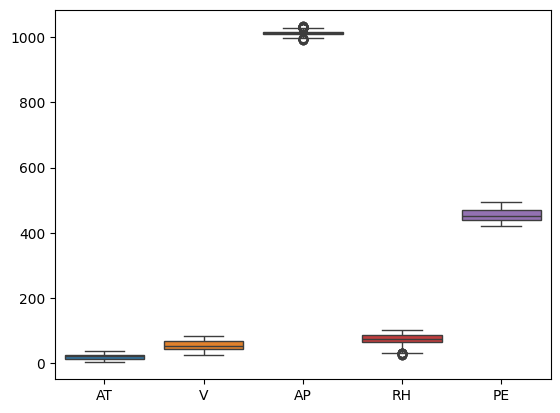

In [14]:
# Checking for outliers
sns.boxplot(df)

In [15]:
# Using IQR to detect outliers
Q1 = df['AP'].quantile(0.25)
Q3 = df['AP'].quantile(0.75)
IQR = Q3 - Q1

#Checking for outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AP'] < lower_bound) | (df['AP'] > upper_bound)]
print(len(outliers))

# Capping the outliers back to df

df['AP'] = np.where(df['AP'] > upper_bound, upper_bound, df['AP'])
df['AP'] = np.where(df['AP'] < lower_bound, lower_bound, df['AP'])


88


In [16]:
# Using IQR to detect outliers
Q1 = df['RH'].quantile(0.25)
Q3 = df['RH'].quantile(0.75)
IQR = Q3 - Q1

#Checking for outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['RH'] < lower_bound) | (df['RH'] > upper_bound)]
print(len(outliers))

# Capping the outliers back to df

df['RH'] = np.where(df['RH'] > upper_bound, upper_bound, df['RH'])
df['RH'] = np.where(df['RH'] < lower_bound, lower_bound, df['RH'])


12


### Define the x and y

In [17]:
x= df.drop('PE', axis=1).values
y= df['PE'].values

In [18]:
# Printing our result

print(x)

[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]
 ...
 [  31.32   74.33 1012.92   36.48]
 [  24.48   69.45 1013.86   62.39]
 [  21.6    62.52 1017.23   67.87]]


In [19]:
# Printing our result

print(y)

[463.26 444.37 488.56 ... 429.57 435.74 453.28]


### Split the dataset in training set and testing set

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

### Train the model on the training set

In [23]:
# Saving the model in an object

model = linear_model.LinearRegression()

# Fitting the model
model.fit(x_train, y_train)

LinearRegression()

### Predict the test set results

In [24]:
y_pred = model.predict(x_test)

# print my output
print(y_pred)

[431.40270057 458.62994496 462.82945797 ... 432.48574825 436.16142931
 439.00390775]


In [25]:
# Testing my model using the existing data from the beginning

model.predict([[14.96, 41.76, 1024.07, 73.17]])

# From the result, the first row in my data actual was (463.26) while my predicted value is 467.36). It is close but not that accurate

array([467.36605924])

### Evaluate the model

In [28]:
from sklearn.metrics import r2_score

# Evaluating my model
r2 = r2_score(y_test, y_pred)

# print the result
print("r2 is: ", r2)

r2 is:  0.930429647725714


In [27]:
# Evaluating further by getting the MAE and RMSE

# Import the model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Checking
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 3.5973471715102554
Root Mean Squared Error (RMSE): 4.512536768690207


### Plot the result

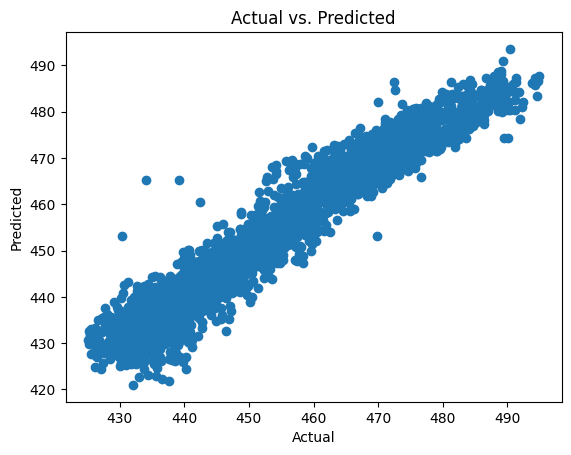

In [36]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

### Predicted *Values*

In [38]:
# Showing our predictions in a dataframe

output = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference':y_test - y_pred })
print(output)

      Actual   Predicted  Difference
0     431.23  431.402701   -0.172701
1     460.01  458.629945    1.380055
2     461.14  462.829458   -1.689458
3     445.90  448.604271   -2.704271
4     451.29  457.892080   -6.602080
...      ...         ...         ...
2866  475.86  472.032532    3.827468
2867  477.94  474.021632    3.918368
2868  426.86  432.485748   -5.625748
2869  433.40  436.161429   -2.761429
2870  441.94  439.003908    2.936092

[2871 rows x 3 columns]


Text(0, 0.5, 'Features')

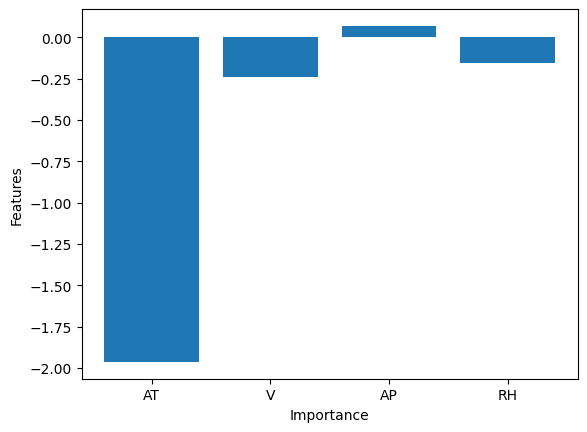

In [40]:
### plotting a bar chart to see the factor with the strongest influence

features = ['AT', 'V', 'AP', 'RH']
importances = model.coef_

plt.bar(features, importances)
plt.xlabel('Importance')
plt.ylabel('Features')